# Preamble

In [510]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy
#np.random.seed(101)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct, Matern
from sklearn.cluster import KMeans


import scipy
from tqdm import tqdm
#import pytorch as torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time


def rbf(x1,x2,width):
    return np.exp(-0.5* (x1-x2)**2/width)

def demonstrate(full_range,y1,f,var,indices,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label="Data",marker=".")
    plt.plot(full_range[indices],f,label="Prediction")
    plt.fill_between(full_range[indices],f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()
    return

def demonstrate_alternate(part_range, y1,f,var, name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(part_range,y1,label="Data")
    plt.plot(part_range,f,label="Prediction")
    plt.fill_between(part_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()
    return

def quick_plot(full_range,f,var,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def quick_plot_alternative(full_range,f,var,index,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,f,label="Prediction")
    plt.fill_between(full_range,f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('f')
    plt.legend()
    plt.grid()
    plt.show()
    return

def state_prep(data, time, order):
        time += 1
        entries = np.min([time,order])
        state = np.zeros((order,2))
        state[(order-entries):order,:] = data[(time-entries):time,:]
        return np.concat((state[:,0].reshape(1,order),state[:,1].reshape(1,order)),axis=1)

def state_prep_loop(data, order):
    states = np.zeros((len(data),2*order))
    for time in range(len(data)): states[time] = state_prep(data, time, order)
    return states

# Data

In [511]:
N=28000
V=7000

full_range = range(N+V)

readout = np.loadtxt('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv',delimiter=',',dtype=float)

readout_u = readout[:,0]
readout_y = readout[:,1]


#norm_u = (np.max(readout_u ) - np.min(readout_u ))
#norm_y = (np.max(readout_y ) - np.min(readout_y ))

norm_u = np.std(readout_u)
norm_y = np.std(readout_y)

mean_u = np.mean(readout_u)
mean_y = np.mean(readout_y)

readout_u = (readout_u-mean_u)/norm_u
readout_y = (readout_y-mean_y)/norm_y

readout_u_tra = readout_u[:N]
readout_y_tra = readout_y[:N]

readout_u_val = readout_u[N:]
readout_y_val = readout_y[N:]

order = 2


x_tra = state_prep_loop(np.concat((readout_u_tra[:,None],readout_y_tra[:,None]),axis=1), order)
y_tra = readout_y_tra[:,None]

x_val = state_prep_loop(np.concat((readout_u_val[:,None],readout_y_val[:,None]),axis=1), order)
y_val = readout_y_val[:,None]


range_tra = np.array(range(N))
range_val = np.array(range(V))

kernel = rbf

#print(readout_u_val)
#print(readout_y_val)
#print(x_val)


# Bayseian committee machine

In [512]:
# Setup

kernel = rbf
width_bcm = 0.5
noise_bcm = 0.1

p_bcm = 80 #no of partitions
M_bcm = 350 #partition block size

N_div = 40
V_div = 1

testpoints_ind_bcm = (np.mod(range(N),N_div)==0)
valipoints_ind_bcm = (np.mod(range(V),V_div)==0)


x_test = x_tra[testpoints_ind_bcm,:]
y_test = y_tra[testpoints_ind_bcm,:]

x_vali = x_val[valipoints_ind_bcm,:]
y_vali = y_val[valipoints_ind_bcm,:]


#[p*M_bcm:((p+1)*M_bcm),:]

#Try to combine SD with BCM?

#hyperinclude_bcm = np.ones([N,p_bcm],dtype='bool')

# + *ExpSineSquared(length_scale=0.5,periodicity=0.5)

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))  + Matern(length_scale=0.5, nu=2.5) #+ ConstantKernel() #DotProduct()   #a=)


In [513]:
np.squeeze(np.array([[1]]))

array(1)

In [514]:
def BCM_predict(x22,reg_bcm, use_norm=False, norm=None, supress_nan=True):#, norm_y = None):
    t_bcm = x22.shape[0]
    prediction_blocks = len(reg_bcm)

    #Initialisation
    f_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    f_bcm_run = np.array(np.zeros(t_bcm))
    var_bcm = f_bcm
    precision = np.array(np.zeros([t_bcm, prediction_blocks]))
    precision_run = np.array(np.zeros([t_bcm]))

    #accumulating and combining predictions
    for i in range(prediction_blocks):
        f_bcm[:,i], precision[:,i] = reg_bcm[i].predict(x22,return_std=True)
        
        #sanity checker ignores the results from experts giving NaN or divide by 0 outputs
        if (precision[:,i].all()>0) and (f_bcm[:,i].all() == f_bcm[:,i].all()): 
            precision[:,i] = precision[:,i]**-1
        else: 
            f_bcm[:,i], precision[:,i] = 0, 0
            prediction_blocks += -1             #This accounts for the reduced number of experts for confidence calculations
        
        precision_run = precision_run + precision[:,i]
        f_bcm_run = f_bcm_run + precision[:,i]*f_bcm[:,i]
    
    #precision_run = precision_run**(1/beta)
    #print(precision_run)
    #K22_factor = np.diag(np.linalg.inv(reg_bcm[0].kernel_(x22)))
    
    K22_factor = np.ones(t_bcm)

    cov_bcm = ( -(prediction_blocks-1)*(K22_factor) + precision_run)**-1

    var_bcm = cov_bcm
    f_bcm = (cov_bcm*f_bcm_run)
    #f_bcm = f_bcm/np.std(f_bcm)

    #mod f_bcm
    if use_norm: f_bcm = f_bcm%(np.sign(f_bcm)*math.pi)

    #if task_mode: return f_bcm#*norm_y
    return f_bcm, var_bcm#/np.std(f_bcm)

def BCM_train(x1,y1,ker_bcm,p_bcm,N,n_restarts_optimizer=10):
    #yeah it's training idk
    reg_bcm = np.zeros([p_bcm],dtype='object')

    #labels = quick_cluster(x1,y1,p_bcm)
    
    for p in tqdm(range(p_bcm)):
        #x11 = x1[np.mod(np.array(range(N))+p,p_bcm)==0]
        #y11 = y1[np.mod(np.array(range(N))+p,p_bcm)==0]
        
        x11 = x1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]
        y11 = y1[int(p*N/p_bcm):int((p+1)*N/p_bcm)]

        #x11 = x1[labels == p]
        #y11 = y1[labels == p]
        
        reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=n_restarts_optimizer, normalize_y=True) #a=)
        reg_bcm[p].fit(x11,y11) #a)
    return reg_bcm

def quick_cluster(x,y, num):
    kmeans = KMeans(n_clusters=num, random_state=0, n_init="auto")
    kmeans.fit(x)
    labels = kmeans.labels_
    return labels


In [515]:
## Training
#bcm_start = time.time()
#
#reg_bcm_pred = BCM_train(x_tra,y_tra,ker_bcm,p_bcm,N)
#
#bcm_end = time.time()
#bcm_run = bcm_end - bcm_start

In [516]:
#f_bcm_test,var_bcm_test = BCM_predict(x_test,reg_bcm,kernel,width_bcm)
#test_rmse = sklearn.metrics.root_mean_squared_error(y_test, f_bcm_test)*norm_y
#
#f_bcm_vali,var_bcm_vali = BCM_predict(x_vali,reg_bcm,kernel,width_bcm)
#vali_rmse = sklearn.metrics.root_mean_squared_error(y_vali, f_bcm_vali)*norm_y

In [517]:

#for p in range(p_bcm): print(reg_bcm[p].kernel_)
#
#name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(N/N_div)) + " test block size"
#demonstrate(range_tra,y_tra,f_bcm_test,var_bcm_test,testpoints_ind_bcm,name)
#
#name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(int(V/V_div)) + " validation block size"
#demonstrate(range_val,y_val,f_bcm_vali,var_bcm_vali,valipoints_ind_bcm,name)
#
#print("test RMSE: ", test_rmse, "\n","validation RMSE: ", vali_rmse )

In [518]:
#test RMSE:  0.007363979744984681 
#validation RMSE:  0.03778853821144124

#print("Log-marginal-likelihood:", reg_bcm[0].log_marginal_likelihood_value_)
#print("Log-marginal-likelihood:", reg_bcm[0].kernel_)

# Predictions task

In [519]:

#data = np.load('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/hidden-test-prediction-submission-file.npz')
#upast_test = data['upast'] #N by u[k-15],u[k-14],...,u[k-1]
#thpast_test = data['thpast'] #N by y[k-15],y[k-14],...,y[k-1]
#Xtest = np.concatenate([upast_test[:,15-order:15], thpast_test[:,15-order:15]],axis=1)
#
##Ypredict, Varpredict = reg_bcm[0].predict(Xtest,return_std=True)
#Ypredict, Varpredict = BCM_predict(Xtest,reg_bcm_pred,kernel,width_bcm)
#
#np.savez('NITIN-hidden-test-prediction-example-submission-file.npz', upast=upast_test, thpast=thpast_test, thnow=Ypredict)
#
#quick_plot(range(len(Xtest)),Ypredict,Varpredict,'predictions idk')
#

# Optuna study

In [531]:
study = optuna.create_study(direction='minimize', storage='sqlite:///example.db', load_if_exists=True)

data = np.load('hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros

predict_handler = lambda x: (BCM_predict(x,reg_bcm))

def simulate_handler(x, reg_bcm):
    return np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True,norm=norm_th)[0]), np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True,norm=norm_th)[1])


def simulation_IO_model(f, reg, ulist, ylist, na, nb, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        #print(u)
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x, reg)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))


[I 2026-06-14 14:44:52,805] A new study created in RDB with name: no-name-d8a3acc4-839f-4a5a-95e3-1ba9b67b453e


In [528]:

def objective(trial):

    # 2. Suggest values of the hyperparameters using a trial object.
    na = trial.suggest_int("na", 3, 6)
    nb = trial.suggest_int("nb", 3, 6)
    nu = trial.suggest_int("nu", 1, 2)

    p_bcm = trial.suggest_int("p_bcm", 5, 20)*10

    Xtrain, Ytrain = create_IO_data(u_train, th_train, na, nb)
    Xval_target, Yval_target = create_IO_data(u_val_target, th_val_target, na, nb)

    initial_length_scales = np.ones(na+nb)*0.5
    ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1)) + Matern(length_scale=initial_length_scales, nu=2.5)  + ConstantKernel(constant_value_bounds=(0.01,10))*ExpSineSquared(length_scale=0.5,periodicity=0.5) #DotProduct()   #a=)

    reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)

    skip = max(na,nb)
    th_train_sim, var_train_sim = simulation_IO_model(simulate_handler, reg_bcm, u_train[:1000], th_train[:1000], na, nb, skip=skip)
    
    return np.mean((th_train_sim[skip:]-th_train[skip:1000])**2)**0.5

# 3. Create a study object and optimize the objective function.



In [532]:
study.optimize(objective, n_trials=10)

print(study.best_params)

 22%|██▏       | 22/100 [02:05<07:26,  5.73s/it]
[W 2026-06-14 14:47:44,258] Trial 0 failed with parameters: {'na': 6, 'nb': 6, 'nu': 1, 'p_bcm': 10} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_103672/2203868194.py", line 16, in objective
    reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_103672/1684156611.py", line 61, in BCM_train
    reg_bcm[p].fit(x11,y11) #a)
    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^

KeyboardInterrupt: 

In [530]:
print(study.best_params)
print(study.best_value)


{'na': 6, 'nb': 4, 'nu': 2, 'p_bcm': 10}
0.16865420119673544


# Simulations task P.1

In [520]:
#Training data maker

V = 7000

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

th_val_target = th_train[:V]
u_val_target = u_train[:V]

th_train = th_train[V:]
u_train =  u_train[V:]

def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        X.append(np.concatenate([u[k-nb:k],y[k-na:k]]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

na = 4
nb = 4

Xtrain, Ytrain = create_IO_data(u_train, th_train, na, nb)
Xval_target, Yval_target = create_IO_data(u_val_target, th_val_target, na, nb)

In [522]:
########## MY SOLUTION

p_bcm = 200 #no of partitions

initial_length_scales = np.ones(na+nb)*0.5

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-6, 1e1)) + Matern(length_scale=initial_length_scales, nu=2.5)  + ConstantKernel(constant_value_bounds=(0.01,10))*ExpSineSquared(length_scale=0.5,periodicity=0.5) #DotProduct()   #a=)

reg_bcm = BCM_train(Xtrain,Ytrain,ker_bcm,p_bcm,len(Ytrain),n_restarts_optimizer=10)

########## MY SOLUTION

 12%|█▏        | 23/200 [00:50<06:29,  2.20s/it]


KeyboardInterrupt: 

WhiteKernel(noise_level=2.12e-05) + Matern(length_scale=[3.67e+04, 5.01e+04, 9.3e+04, 1e+05, 3.93, 1.35e+03, 18.2, 2.74], nu=2.5) + 1.83**2 * ExpSineSquared(length_scale=0.0194, periodicity=3.35e+04)
WhiteKernel(noise_level=6.36e-05) + Matern(length_scale=[1.73e+03, 22.7, 328, 2.04e+04, 3.8, 5.11, 3.07e+04, 2.04], nu=2.5) + 0.1**2 * ExpSineSquared(length_scale=3.15e+03, periodicity=0.000372)
WhiteKernel(noise_level=2.4e-05) + Matern(length_scale=[99.2, 45.5, 2.99e+03, 322, 2.65, 11.6, 1e+05, 2.35], nu=2.5) + 0.1**2 * ExpSineSquared(length_scale=3.39, periodicity=7.48e+04)
WhiteKernel(noise_level=8.06e-05) + Matern(length_scale=[42.2, 8.39e+04, 42.9, 4.95e+04, 2.51e+04, 1.19, 3.84e+03, 1.08], nu=2.5) + 0.1**2 * ExpSineSquared(length_scale=1e+05, periodicity=46.1)
WhiteKernel(noise_level=3.87e-05) + Matern(length_scale=[49.1, 8.42e+03, 42.4, 1e+05, 2.86, 6.77, 1.17e+03, 2.27], nu=2.5) + 0.1**2 * ExpSineSquared(length_scale=2.55e+03, periodicity=169)
WhiteKernel(noise_level=5.09e-05) + Ma

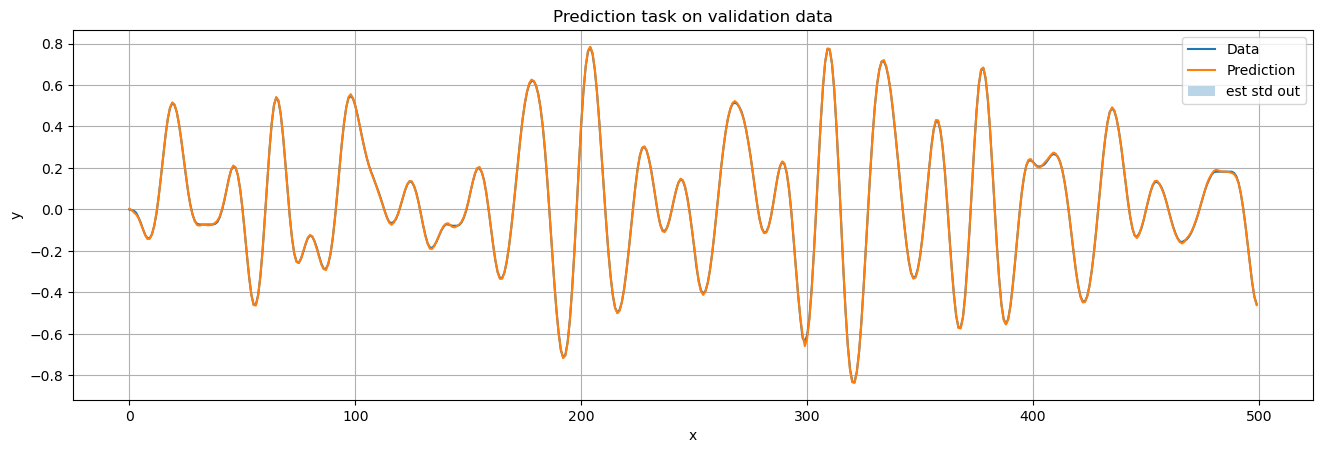

In [ ]:
predict_handler = lambda x: (BCM_predict(x,reg_bcm))

def simulate_handler(x):
    return np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True,norm=norm_th)[0]), np.squeeze(BCM_predict(x[None,:],reg_bcm,use_norm=True,norm=norm_th)[1])

for p in range(p_bcm): print(reg_bcm[p].kernel_)

indices_pred = np.array(range(len(Xval_target)))<500      #Predict on only 500 points to save time

part_range = np.array(range(500))

Ytrain_pred, var_train_pred = predict_handler(Xval_target[indices_pred]) 

demonstrate_alternate(part_range, Yval_target[indices_pred], Ytrain_pred , var_train_pred , "Prediction task on validation data")


# Simulation task P.2 

In [ ]:
data = np.load('hidden-test-simulation-submission-file.npz')
u_test = data['u']
th_test = data['th'] #only the first 50 values are filled the rest are zeros

#norm_th = np.std(th_test)
#norm_u = np.std(u_test)

#u_test, th_test = u_test/norm_u, th_test/norm_th

#print(norm_x)
#print(norm_y)

def simulation_IO_model(f, ulist, ylist, skip=50):
    
    upast = ulist[skip-nb:skip].tolist() #good initialization
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    var = []
    for u in tqdm(ulist[skip:]):
        #print(u)
        x = np.concatenate([upast,ypast],axis=0)
        ypred, v = f(x)
        var.append(v)
        Y.append(ypred)
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y), np.concat((np.zeros(max(na,nb)),np.array(var)))




In [ ]:
skip = max(na,nb)

th_train_sim, var_train_sim = simulation_IO_model(simulate_handler, u_train[:1000], th_train[:1000], skip=skip)

skip = 50

th_test_sim,  var_test_sim = simulation_IO_model(simulate_handler, u_test[:1000], th_test[:1000], skip=skip)

assert len(th_test_sim)==len(th_test[:1000])
np.savez('hidden-test-simulation-NITIN-submission-file.npz', th=th_test_sim, u=u_test)




100%|██████████| 950/950 [00:22<00:00, 41.86it/s]


1000


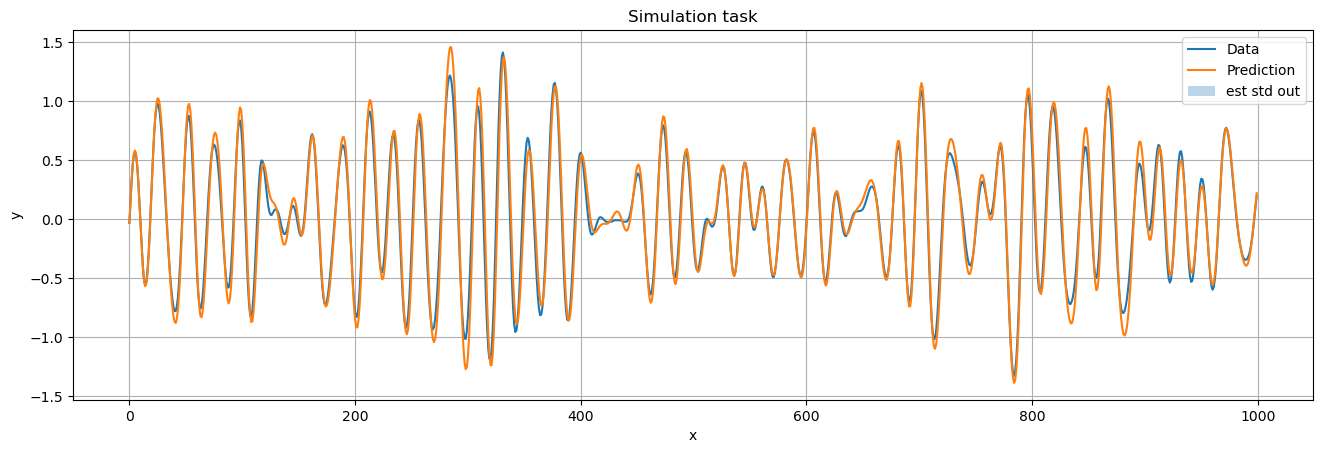

In [ ]:
print(len(var_train_sim))

demonstrate_alternate(full_range[:1000], th_train[:1000], th_train_sim, var_train_sim, "Simulation task")

# Results

In [ ]:

print('training prediction errors:')
print('RMS:',  np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5,'radians')
print('RMS:',  np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((Yval_target[indices_pred]-Ytrain_pred)**2)**0.5/Ytrain.std()*100,'%')

print('training simulation errors:')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:1000])**2)**0.5,'radians')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:1000])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_train_sim[skip:]-th_train[skip:1000])**2)**0.5/th_train.std()*100,'%')

training prediction errors:
RMS: 0.0037028611265097723 radians
RMS: 0.21215831467206756 degrees
NRMS: 0.7774740111132961 %
training simulation errors:
RMS: 0.10837320136768717 radians
RMS: 6.209327050689876 degrees
NRMS: 22.75575655618472 %
